In [1]:
import matplotlib.pyplot as plt
import pandas as pd

import scarf

scarf.configure_output(level="WARNING", progress=False)

dataset = scarf.cytebase.connect("scarf_docs").download_dataset(
    "swanson_7K_pbmc_teaseq",
    destination="scarf_datasets",
    zarr=True,
)
ds = scarf.DataStore(
    f"{dataset}/data.zarr",
    default_assay="RNA",
    nthreads=4,
)

In [2]:
pd.DataFrame.from_dict(
    {
        assay: {
            "cells": ds.get_assay(assay).rawData.shape[0],
            "raw features": ds.get_assay(assay).rawData.shape[1],
            "active features": int(
                ds.get_assay(assay).feats.fetch_all("I").sum()
            ),
        }
        for assay in ("RNA", "ATAC", "ADT")
    },
    orient="index",
)

,cells,raw features,active features
RNA,7069,36601,36601
ATAC,7069,240122,240122
ADT,7069,46,46


In [3]:
modality_layouts = {}
for assay in ("RNA", "ATAC", "ADT"):
    [modality_layouts[assay]] = ds.list_artifacts(
        from_assay=assay,
        kind="embedding",
        operation="run_umap",
        complete_only=True,
    )

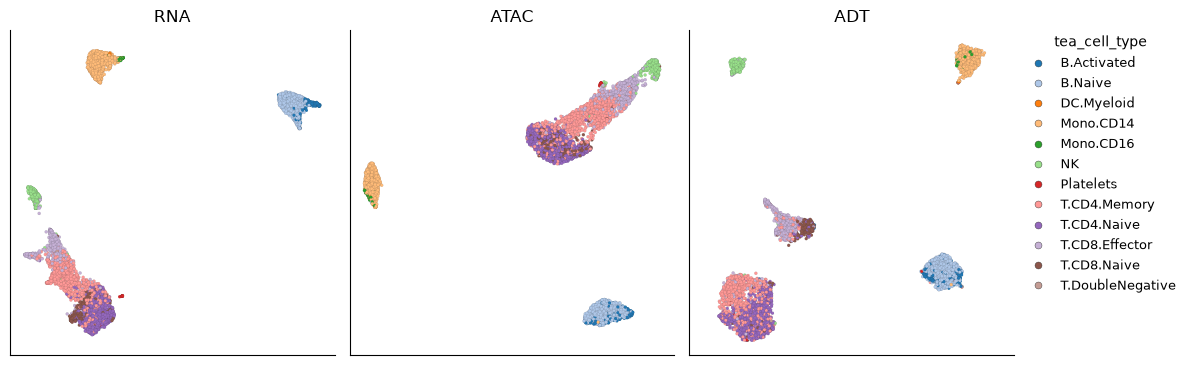

In [4]:
figure, axes = plt.subplots(1, 3, figsize=(12, 4))
for axis, (assay, layout) in zip(
    axes,
    modality_layouts.items(),
    strict=True,
):
    ds.plots.embedding(
        layout=layout,
        color_by="tea_cell_type",
        point_size=5,
        legend_loc="right" if assay == "ADT" else "none",
        show_titles=False,
        target=axis,
        show=False,
    )
    axis.set_title(assay)
figure.tight_layout()

In [5]:
[wnn_graph] = ds.list_artifacts(
    scope="datastore",
    kind="integrated_graph",
    operation="integrate_assays",
    parameters={"method": "wnn"},
    complete_only=True,
)
[wnn_layout] = ds.list_artifacts(
    scope="datastore",
    kind="embedding",
    operation="run_umap",
    inputs={"graph": wnn_graph},
    complete_only=True,
)

wnn_status = ds.inspect_artifact(wnn_graph)
assert wnn_status.parameters["assays"] == ["RNA", "ATAC", "ADT"]
pd.Series(
    {
        "artifact": wnn_graph.artifact_id,
        "ordered assays": ", ".join(wnn_status.parameters["assays"]),
        "complete": wnn_status.complete,
    }
)

artifact          58496f13c7f4aa93f08f8773704ce29e5450f6c6751060...
ordered assays                                       RNA, ATAC, ADT
complete                                                       True
dtype: object

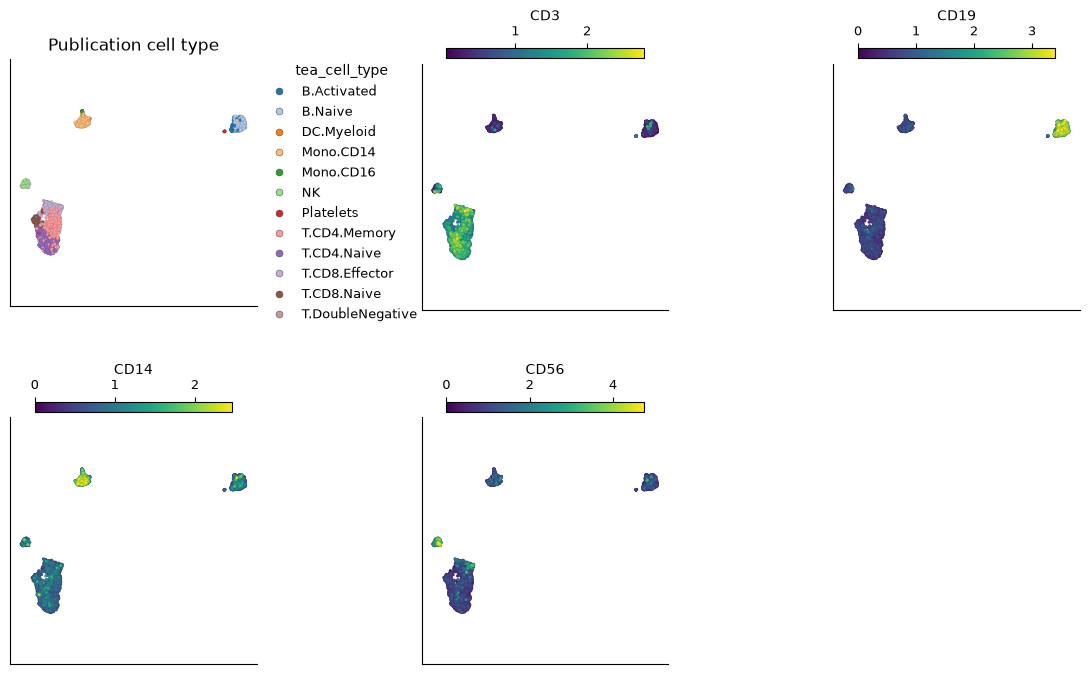

In [6]:
figure, axes = plt.subplots(2, 3, figsize=(11, 7))
panels = (
    (None, None, "Publication cell type"),
    ("CD3", "ADT", None),
    ("CD19", "ADT", None),
    ("CD14", "ADT", None),
    ("CD56", "ADT", None),
)
for axis, (color_by, assay, title) in zip(
    axes.flat,
    panels,
    strict=False,
):
    ds.plots.embedding(
        layout=wnn_layout,
        color_by="tea_cell_type" if color_by is None else color_by,
        from_assay=assay,
        point_size=5,
        sort_values=color_by is not None,
        legend_loc="right" if color_by is None else "auto",
        show_titles=False,
        target=axis,
        show=False,
    )
    if title is not None:
        axis.set_title(title)
axes.flat[-1].set_visible(False)
figure.tight_layout()

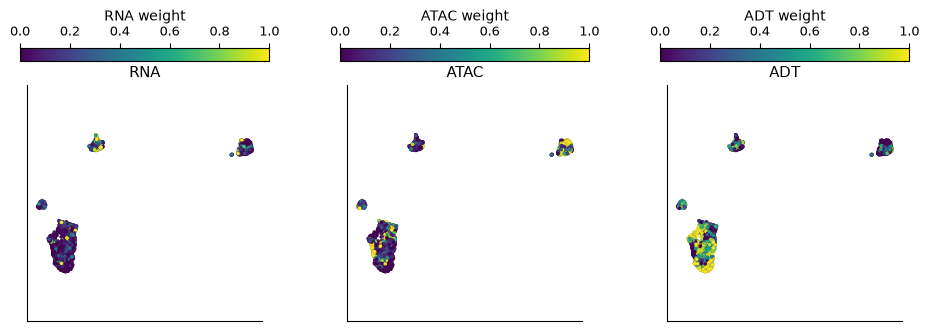

In [7]:
ds.plots.modality_weights(
    graph=wnn_graph,
    layout=wnn_layout,
)